# PI source-domain few-shot diagnostic

This notebook checks whether the few-shot prototype behavior already fails before the PI-4a domain shift.

It evaluates K-shot prototype inference on source domains only:

- enrollment: PI-1a, PI-2a, PI-3a, split 0.0-0.6
- query: PI-1a, PI-2a, PI-3a, split 0.6-0.8

Models compared:

- softmax-trained SHARP feature-map embeddings
- old prototypical model using raw SHARP feature-map embeddings
- new prototypical model using the 128-D projection head


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

RUN_GROUP = "few_shot_source_domain_evaluation"
RUN_NAME = "source_domain_featuremap_vs_projection"

DOPPLER_DIR = PROJECT_ROOT / "data" / "doppler_traces_pi"

SOFTMAX_CHECKPOINT = PROJECT_ROOT / "experiments" / "pi_classification" / "pi_all_persons_123_train_4_test_sharp_model_20260525_165437" / "model.pt"
OLD_PROTO_FEATUREMAP_CHECKPOINT = PROJECT_ROOT / "experiments" / "few_shot_proto_evaluation" / "proto_multi_antenna_vs_softmax_baseline_20260527_164722" / "proto_model.pt"
NEW_PROTO_ENCODER_CHECKPOINT = PROJECT_ROOT / "experiments" / "few_shot_proto_evaluation" / "proto_multi_antenna_vs_softmax_baseline_20260528_184419" / "proto_model_best.pt"

SOURCE_SCENARIOS = ["PI-1a", "PI-2a", "PI-3a"]
PERSONS = ["p03", "p05", "p06", "p07", "p08", "p09", "p10", "p11", "p12", "p13"]

ENROLLMENT_SPLIT = (0.0, 0.6)
QUERY_SPLIT = (0.6, 0.8)
WINDOW_SIZE = 340
WINDOW_STRIDE = 30

K_VALUES = [1, 3, 5, 10, 25, 50, 100]
N_TRIALS = 20
BATCH_SIZE = 128
SEED = 0
EMBEDDING_FUSION = "mean"
METRIC = "cosine"


In [2]:
import json

import matplotlib.pyplot as plt
import torch

from wifi_doppler.data.dataset import DopplerWindowDataset
from wifi_doppler.evaluation.fewshot import evaluate_kshot
from wifi_doppler.experiments.artifacts import create_run_dir, save_figure, save_json
from wifi_doppler.models.sharp import (
    MultiAntennaEncoder,
    MultiAntennaModel,
    SharpSingleAntennaEncoder,
    SingleAntennaModel,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## Source-domain datasets

The query set is held out in time from the same PI-1a, PI-2a, PI-3a domains used for enrollment/training.

In [3]:
source_enrollment_dataset = DopplerWindowDataset(
    DOPPLER_DIR,
    scenarios=SOURCE_SCENARIOS,
    split=ENROLLMENT_SPLIT,
    window_size=WINDOW_SIZE,
    window_stride=WINDOW_STRIDE,
    labels=PERSONS,
)

source_query_dataset = DopplerWindowDataset(
    DOPPLER_DIR,
    scenarios=SOURCE_SCENARIOS,
    split=QUERY_SPLIT,
    window_size=WINDOW_SIZE,
    window_stride=WINDOW_STRIDE,
    labels=PERSONS,
)

print("source enrollment windows:", len(source_enrollment_dataset))
print("source query windows:", len(source_query_dataset))
print("labels:", source_enrollment_dataset.labels)


source enrollment windows: 26801
source query windows: 8685
labels: ('p03', 'p05', 'p06', 'p07', 'p08', 'p09', 'p10', 'p11', 'p12', 'p13')


## Model loading

The legacy SHARP model exposes flattened convolutional feature maps through `forward_embedding`. The new encoder exposes the 128-D projection-head output.

In [4]:
def load_checkpoint(path: Path):
    if not path.exists():
        raise FileNotFoundError(path)
    return torch.load(path, map_location=device, weights_only=False)


def load_state_dict_with_lazy_init(model: torch.nn.Module, checkpoint: dict, *, use_forward: bool = False):
    state_dict = checkpoint["model_state_dict"]
    try:
        model.load_state_dict(state_dict)
    except RuntimeError:
        dummy = torch.zeros(1, 4, WINDOW_SIZE, 100, device=device)
        with torch.no_grad():
            if use_forward:
                model(dummy)
            else:
                model.forward_embedding(dummy, fusion=EMBEDDING_FUSION)
        model.load_state_dict(state_dict)
    model.eval()
    return model


def build_legacy_featuremap_model(checkpoint_path: Path):
    checkpoint = load_checkpoint(checkpoint_path)
    model = MultiAntennaModel(SingleAntennaModel(num_classes=len(PERSONS))).to(device)
    return load_state_dict_with_lazy_init(model, checkpoint, use_forward=True), checkpoint


def build_new_proto_encoder(checkpoint_path: Path):
    checkpoint = load_checkpoint(checkpoint_path)
    config = checkpoint.get("config", {})
    model = MultiAntennaEncoder(
        SharpSingleAntennaEncoder(
            embedding_dim=int(config.get("proto_embedding_dim", 128)),
            hidden_dim=int(config.get("proto_hidden_dim", 256)),
            normalize=True,
        )
    ).to(device)
    return load_state_dict_with_lazy_init(model, checkpoint), checkpoint


softmax_featuremap_model, softmax_checkpoint = build_legacy_featuremap_model(SOFTMAX_CHECKPOINT)
old_proto_featuremap_model, old_proto_checkpoint = build_legacy_featuremap_model(OLD_PROTO_FEATUREMAP_CHECKPOINT)
new_proto_encoder_model, new_proto_checkpoint = build_new_proto_encoder(NEW_PROTO_ENCODER_CHECKPOINT)

print("loaded softmax feature-map checkpoint:", SOFTMAX_CHECKPOINT)
print("loaded old proto feature-map checkpoint:", OLD_PROTO_FEATUREMAP_CHECKPOINT)
print("loaded new proto encoder checkpoint:", NEW_PROTO_ENCODER_CHECKPOINT)


loaded softmax feature-map checkpoint: c:\Users\gianm\Development\wifi-doppler-har\experiments\pi_classification\pi_all_persons_123_train_4_test_sharp_model_20260525_165437\model.pt
loaded old proto feature-map checkpoint: c:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_proto_evaluation\proto_multi_antenna_vs_softmax_baseline_20260527_164722\proto_model.pt
loaded new proto encoder checkpoint: c:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_proto_evaluation\proto_multi_antenna_vs_softmax_baseline_20260528_184419\proto_model_best.pt


In [5]:
def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())


with torch.no_grad():
    sample_x, _ = source_query_dataset[0]
    sample_x = sample_x.unsqueeze(0).to(device)
    model_summaries = {
        "softmax_featuremap": {
            "embedding_shape": tuple(softmax_featuremap_model.forward_embedding(sample_x, fusion=EMBEDDING_FUSION).shape),
            "parameters": count_parameters(softmax_featuremap_model),
        },
        "old_proto_featuremap": {
            "embedding_shape": tuple(old_proto_featuremap_model.forward_embedding(sample_x, fusion=EMBEDDING_FUSION).shape),
            "parameters": count_parameters(old_proto_featuremap_model),
        },
        "new_proto_encoder": {
            "embedding_shape": tuple(new_proto_encoder_model.forward_embedding(sample_x, fusion=EMBEDDING_FUSION).shape),
            "parameters": count_parameters(new_proto_encoder_model),
        },
    }

print(json.dumps(model_summaries, indent=2))


{
  "softmax_featuremap": {
    "embedding_shape": [
      1,
      25500
    ],
    "parameters": 256040
  },
  "old_proto_featuremap": {
    "embedding_shape": [
      1,
      25500
    ],
    "parameters": 256040
  },
  "new_proto_encoder": {
    "embedding_shape": [
      1,
      128
    ],
    "parameters": 6562182
  }
}


c:\Users\gianm\anaconda3\envs\wifi-doppler-har\Lib\site-packages\torch\nn\modules\conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1091.)
  return F.conv2d(


## K-shot source-domain evaluation

In [6]:
def run_kshot_eval(name: str, model: torch.nn.Module):
    print(f"evaluating {name}...")
    results = evaluate_kshot(
        model,
        source_enrollment_dataset,
        source_query_dataset,
        K_VALUES,
        device,
        n_trials=N_TRIALS,
        seed=SEED,
        batch_size=BATCH_SIZE,
        embedding_fusion=EMBEDDING_FUSION,
        metric=METRIC,
    )
    for k in K_VALUES:
        result = results[k]
        print(f"  K={k:>3}: {result['mean']:.4f} +/- {result['std']:.4f}")
    return results


source_results = {
    "softmax_featuremap": run_kshot_eval("softmax feature-map embeddings", softmax_featuremap_model),
    "old_proto_featuremap": run_kshot_eval("old proto feature-map embeddings", old_proto_featuremap_model),
    "new_proto_encoder": run_kshot_eval("new 128-D proto encoder", new_proto_encoder_model),
}

source_enrollment_dataset.clear_cache()
source_query_dataset.clear_cache()


evaluating softmax feature-map embeddings...
  K=  1: 0.1727 +/- 0.0335
  K=  3: 0.2346 +/- 0.0296
  K=  5: 0.2390 +/- 0.0429
  K= 10: 0.2499 +/- 0.0408
  K= 25: 0.2800 +/- 0.0318
  K= 50: 0.2988 +/- 0.0289
  K=100: 0.2949 +/- 0.0174
evaluating old proto feature-map embeddings...
  K=  1: 0.2361 +/- 0.0409
  K=  3: 0.2547 +/- 0.0345
  K=  5: 0.2715 +/- 0.0281
  K= 10: 0.2702 +/- 0.0338
  K= 25: 0.2672 +/- 0.0274
  K= 50: 0.2684 +/- 0.0232
  K=100: 0.2629 +/- 0.0245
evaluating new 128-D proto encoder...
  K=  1: 0.2181 +/- 0.0370
  K=  3: 0.2691 +/- 0.0363
  K=  5: 0.2712 +/- 0.0243
  K= 10: 0.2889 +/- 0.0249
  K= 25: 0.2905 +/- 0.0157
  K= 50: 0.2980 +/- 0.0151
  K=100: 0.3014 +/- 0.0117


## Plot and save artifacts

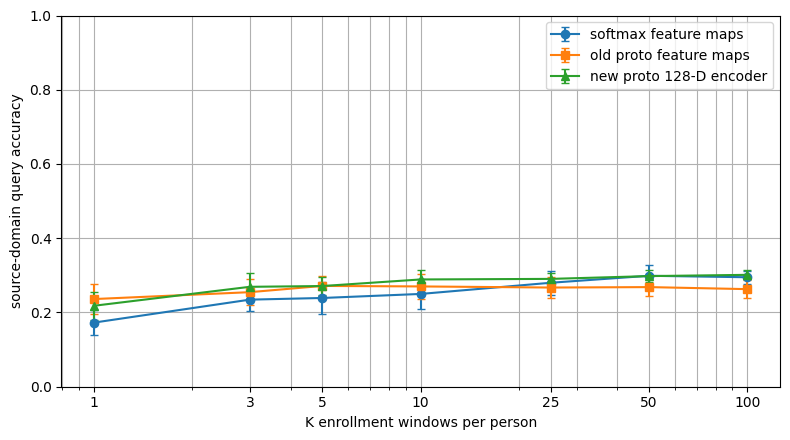

In [7]:
def result_series(results, k_values):
    means = [results[k]["mean"] for k in k_values]
    stds = [results[k]["std"] for k in k_values]
    return means, stds


fig, ax = plt.subplots(figsize=(8, 4.5))
series_styles = {
    "softmax_featuremap": {"label": "softmax feature maps", "marker": "o"},
    "old_proto_featuremap": {"label": "old proto feature maps", "marker": "s"},
    "new_proto_encoder": {"label": "new proto 128-D encoder", "marker": "^"},
}

for name, style in series_styles.items():
    means, stds = result_series(source_results[name], K_VALUES)
    ax.errorbar(K_VALUES, means, yerr=stds, marker=style["marker"], capsize=3, label=style["label"])

ax.set_xscale("log")
ax.set_xticks(K_VALUES)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_ylim(0, 1)
ax.set_xlabel("K enrollment windows per person")
ax.set_ylabel("source-domain query accuracy")
ax.grid(True, which="both")
ax.legend()
fig.tight_layout()
plt.show()


In [8]:
run_dir = create_run_dir(PROJECT_ROOT, RUN_GROUP, RUN_NAME)

config = {
    "doppler_dir": DOPPLER_DIR,
    "source_scenarios": SOURCE_SCENARIOS,
    "persons": PERSONS,
    "enrollment_split": ENROLLMENT_SPLIT,
    "query_split": QUERY_SPLIT,
    "window_size": WINDOW_SIZE,
    "window_stride": WINDOW_STRIDE,
    "k_values": K_VALUES,
    "n_trials": N_TRIALS,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "embedding_fusion": EMBEDDING_FUSION,
    "metric": METRIC,
    "softmax_checkpoint": SOFTMAX_CHECKPOINT,
    "old_proto_featuremap_checkpoint": OLD_PROTO_FEATUREMAP_CHECKPOINT,
    "new_proto_encoder_checkpoint": NEW_PROTO_ENCODER_CHECKPOINT,
    "model_summaries": model_summaries,
}

plot_path = save_figure(fig, run_dir, "source_domain_kshot_comparison.png")
results_path = save_json(run_dir / "source_domain_kshot_results.json", {
    "config": config,
    "source_results": source_results,
})

print("Run directory:", run_dir)
print("Plot:", plot_path)
print("Results:", results_path)


Run directory: c:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_source_domain_evaluation\source_domain_featuremap_vs_projection_20260528_200640
Plot: c:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_source_domain_evaluation\source_domain_featuremap_vs_projection_20260528_200640\source_domain_kshot_comparison.png
Results: c:\Users\gianm\Development\wifi-doppler-har\experiments\few_shot_source_domain_evaluation\source_domain_featuremap_vs_projection_20260528_200640\source_domain_kshot_results.json
